# <b><u><center><h1><font color = 'Purple'>Analysis of Cancer Risk Factors
<div style="width:100%; text-align:center;">
    <img src="https://geimshospital.com/wp-content/uploads/2026/02/Cancer-Risk-Factors-img.jpg"
         style="width:100%; max-height:320px; object-fit:cover; border-radius:14px;">
</div>

#### <p><i>  Cancer is a complex disease influenced by a combination of genetic, environmental, and lifestyle-related factors. Understanding these risk factors is essential for early detection, prevention strategies, and improved public health outcomes. In this project, we analyze a cancer risk dataset containing clinical variables, lifestyle behaviors, and biological indicators. The dataset includes factors such as smoking habits, alcohol consumption, dietary patterns (including red meat intake and fruit/vegetable consumption), physical activity levels, exposure to air pollution, occupational hazards, and family history of cancer. Additionally, the analysis incorporates non-modifiable biological markers such as genetic mutations (e.g., BRCA mutations), which play a critical role in understanding inherited cancer risks.Through exploratory data analysis and visualization techniques, this project aims to identify patterns and relationships between these risk factors and different types of cancer.

## <i><u>Objective of the Study

### <i> The main objectives of this project are:

#### <i> 1. To explore and understand the distribution of cancer cases across different cancer types.
#### <i>2. To analyze lifestyle-related risk factors such as smoking, alcohol consumption, diet, and physical activity.
#### <i>3. To examine environmental influences including air pollution and occupational exposure.
#### <i>4. To study the role of family history and genetic mutations (BRCA) in cancer risk.
#### <i>5. To identify patterns and potential relationships between modifiable and non-modifiable risk factors.
#### <i>6. To generate meaningful insights using data visualization and statistical analysis.
#### <i>7. To support better understanding of cancer risk factors through data-driven exploration.

<hr style="height:3px;border:none;background:linear-gradient(to right,#6c63ff,#00c9a7);">

## <font color = 'purple'>1. Data Loading and Initial Overview.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('cancer-risk-factors.csv')
df

,Patient_ID,Cancer_Type,Age,Gender,Smoking,Alcohol_Use,Obesity,Family_History,Diet_Red_Meat,Diet_Salted_Processed,...,Physical_Activity,Air_Pollution,Occupational_Hazards,BRCA_Mutation,H_Pylori_Infection,Calcium_Intake,Overall_Risk_Score,BMI,Physical_Activity_Level,Risk_Level
0,LU0000,Breast,68,0,7,2,8,0,5,3,...,4,6,3,1,0,0,0.398696,28.0,5,Medium
1,LU0001,Prostate,74,1,8,9,8,0,0,3,...,1,3,3,0,0,5,0.424299,25.4,9,Medium
2,LU0002,Skin,55,1,7,10,7,0,3,3,...,1,8,10,0,0,6,0.605082,28.6,2,Medium
3,LU0003,Colon,61,0,6,2,2,0,6,2,...,6,4,8,0,0,8,0.318449,32.1,7,Low
4,LU0004,Lung,67,1,10,7,4,0,6,3,...,9,10,9,0,0,5,0.524358,25.1,2,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,ST0395,Colon,60,1,4,6,4,0,10,6,...,4,5,3,1,0,4,0.437539,30.3,3,Medium
1996,ST0396,Prostate,84,1,5,7,8,0,10,0,...,2,1,3,0,0,2,0.451128,25.9,4,Medium
1997,ST0397,Lung,65,0,7,2,10,0,4,2,...,3,6,0,0,1,0,0.295760,22.5,3,Low
1998,ST0398,Lung,64,1,10,2,10,0,2,10,...,5,4,2,0,0,10,0.422201,25.3,3,Medium


In [3]:
df.head()

,Patient_ID,Cancer_Type,Age,Gender,Smoking,Alcohol_Use,Obesity,Family_History,Diet_Red_Meat,Diet_Salted_Processed,...,Physical_Activity,Air_Pollution,Occupational_Hazards,BRCA_Mutation,H_Pylori_Infection,Calcium_Intake,Overall_Risk_Score,BMI,Physical_Activity_Level,Risk_Level
0,LU0000,Breast,68,0,7,2,8,0,5,3,...,4,6,3,1,0,0,0.398696,28.0,5,Medium
1,LU0001,Prostate,74,1,8,9,8,0,0,3,...,1,3,3,0,0,5,0.424299,25.4,9,Medium
2,LU0002,Skin,55,1,7,10,7,0,3,3,...,1,8,10,0,0,6,0.605082,28.6,2,Medium
3,LU0003,Colon,61,0,6,2,2,0,6,2,...,6,4,8,0,0,8,0.318449,32.1,7,Low
4,LU0004,Lung,67,1,10,7,4,0,6,3,...,9,10,9,0,0,5,0.524358,25.1,2,Medium


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Patient_ID               2000 non-null   object 
 1   Cancer_Type              2000 non-null   object 
 2   Age                      2000 non-null   int64  
 3   Gender                   2000 non-null   int64  
 4   Smoking                  2000 non-null   int64  
 5   Alcohol_Use              2000 non-null   int64  
 6   Obesity                  2000 non-null   int64  
 7   Family_History           2000 non-null   int64  
 8   Diet_Red_Meat            2000 non-null   int64  
 9   Diet_Salted_Processed    2000 non-null   int64  
 10  Fruit_Veg_Intake         2000 non-null   int64  
 11  Physical_Activity        2000 non-null   int64  
 12  Air_Pollution            2000 non-null   int64  
 13  Occupational_Hazards     2000 non-null   int64  
 14  BRCA_Mutation           

In [5]:
df.shape

(2000, 21)

In [6]:
df.describe()

,Age,Gender,Smoking,Alcohol_Use,Obesity,Family_History,Diet_Red_Meat,Diet_Salted_Processed,Fruit_Veg_Intake,Physical_Activity,Air_Pollution,Occupational_Hazards,BRCA_Mutation,H_Pylori_Infection,Calcium_Intake,Overall_Risk_Score,BMI,Physical_Activity_Level
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.00000,2000.000000,2000.000000,2000.000000
mean,63.248000,0.489000,5.157000,5.035000,5.967500,0.194500,5.189500,4.563500,4.927500,4.015000,5.323000,4.979000,0.032500,0.19650,3.94050,0.454449,26.183350,4.938500
std,10.462946,0.500004,3.325339,3.260996,3.061393,0.395914,3.154452,3.088323,3.045305,2.978458,3.207462,3.212899,0.177368,0.39745,3.04887,0.123074,3.947459,3.166027
min,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000,0.029285,15.000000,0.000000
25%,56.000000,0.000000,2.000000,2.000000,4.000000,0.000000,3.000000,2.000000,3.000000,1.000000,3.000000,2.000000,0.000000,0.00000,1.00000,0.366982,23.500000,2.000000
50%,64.000000,0.000000,5.000000,5.000000,6.000000,0.000000,5.000000,4.000000,5.000000,4.000000,5.000000,5.000000,0.000000,0.00000,4.00000,0.455399,26.200000,5.000000
75%,70.000000,1.000000,8.000000,8.000000,9.000000,0.000000,8.000000,7.000000,8.000000,6.000000,8.000000,8.000000,0.000000,0.00000,6.00000,0.539782,28.700000,8.000000
max,90.000000,1.000000,10.000000,10.000000,10.000000,1.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,1.000000,1.00000,10.00000,0.852158,41.400000,10.000000


In [7]:
df.describe(include = 'O')

,Patient_ID,Cancer_Type,Risk_Level
count,2000,2000,2000
unique,2000,5,3
top,ST0383,Lung,Medium
freq,1,527,1574


In [8]:
df.isnull().sum()

Patient_ID                 0
Cancer_Type                0
Age                        0
Gender                     0
Smoking                    0
Alcohol_Use                0
Obesity                    0
Family_History             0
Diet_Red_Meat              0
Diet_Salted_Processed      0
Fruit_Veg_Intake           0
Physical_Activity          0
Air_Pollution              0
Occupational_Hazards       0
BRCA_Mutation              0
H_Pylori_Infection         0
Calcium_Intake             0
Overall_Risk_Score         0
BMI                        0
Physical_Activity_Level    0
Risk_Level                 0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.dtypes

Patient_ID                  object
Cancer_Type                 object
Age                          int64
Gender                       int64
Smoking                      int64
Alcohol_Use                  int64
Obesity                      int64
Family_History               int64
Diet_Red_Meat                int64
Diet_Salted_Processed        int64
Fruit_Veg_Intake             int64
Physical_Activity            int64
Air_Pollution                int64
Occupational_Hazards         int64
BRCA_Mutation                int64
H_Pylori_Infection           int64
Calcium_Intake               int64
Overall_Risk_Score         float64
BMI                        float64
Physical_Activity_Level      int64
Risk_Level                  object
dtype: object

<hr style="height:3px;border:none;background:linear-gradient(to right,#6c63ff,#00c9a7);">

<div style="width:90%; text-align:center;">
    <img src="https://mci.ac.ir/images/www/en/page/editor/2023/65265289bd669-7.png"
         style="width:100%; max-height:320px; object-fit:cover; border-radius:14px;">
</div>

## <font color = 'purple'><u> Data Pre-processing.

In [12]:
df['Gender'] = df['Gender'].map({0:'Female', 1:'Male'})
df['Gender'] = df['Gender'].astype('category')

In [13]:
bins = [25, 40, 60, 75, 91]
labels = ['Young (25-39)', 
          'Middle-aged (40-59)', 
          'Senior (60-74)', 
          'Elderly (75+)']

df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)

In [14]:
df['Age_Group'].value_counts()

Age_Group
Senior (60-74)         1043
Middle-aged (40-59)     648
Elderly (75+)           278
Young (25-39)            31
Name: count, dtype: int64

#### <i><font color = 'red'> * Peak incidence is between 60–74 years.

In [15]:
df['Risk_Level'].value_counts()

Risk_Level
Medium    1574
Low        324
High       102
Name: count, dtype: int64

In [16]:
df['Risk_Level'] = pd.Categorical(
    df['Risk_Level'],
    categories=['Low','Medium','High'],
    ordered=True)

#### <i><font color = 'red'> * Most patients falls under medium risk category.

In [17]:
df['H_Pylori_Infection'] = df['H_Pylori_Infection'].map({0: 'No', 1: 'Yes'})
df['H_Pylori_Infection'] = df['H_Pylori_Infection'].astype('category')

In [18]:
df['BRCA_Mutation'] = df['BRCA_Mutation'].map({0: 'No', 1: 'Yes'})
df['BRCA_Mutation'] = df['BRCA_Mutation'].astype('category')

<hr style="height:3px;border:none;background:linear-gradient(to right,#6c63ff,#00c9a7);">

## <u><font color = 'purple'>Exploratory Data Analysis & Visualzations.

In [19]:
df.groupby('Risk_Level', observed = False)['Overall_Risk_Score'].describe()

,count,mean,std,min,25%,50%,75%,max
Risk_Level,,,,,,,,
Low,324.0,0.269458,0.049212,0.029285,0.245686,0.279642,0.305975,0.329922
Medium,1574.0,0.476616,0.084961,0.330033,0.408240,0.471638,0.540578,0.659130
High,102.0,0.699991,0.036094,0.660797,0.671104,0.688083,0.714806,0.852158


#### <i>&bull;  High-risk cases are few - (102/2000 = 5.1%).
#### <i>&bull;  The distribution reflects the fact that most patients’ Overall_Risk_Score is in the middle range (~0.45), consistent with the thresholds.

<hr style="height:3px;border:none;background:linear-gradient(to right,#6c63ff,#00c9a7);">

In [20]:
plt.style.use('ggplot')

<div style="display:flex; align-items:center; gap:20px;">
    <img src="https://cdn-icons-png.flaticon.com/512/706/706161.png"
         width="210">
 <h1><u><I><center><b>  <p> Number of patients by Cancer Types.</center></h2> 
</div>


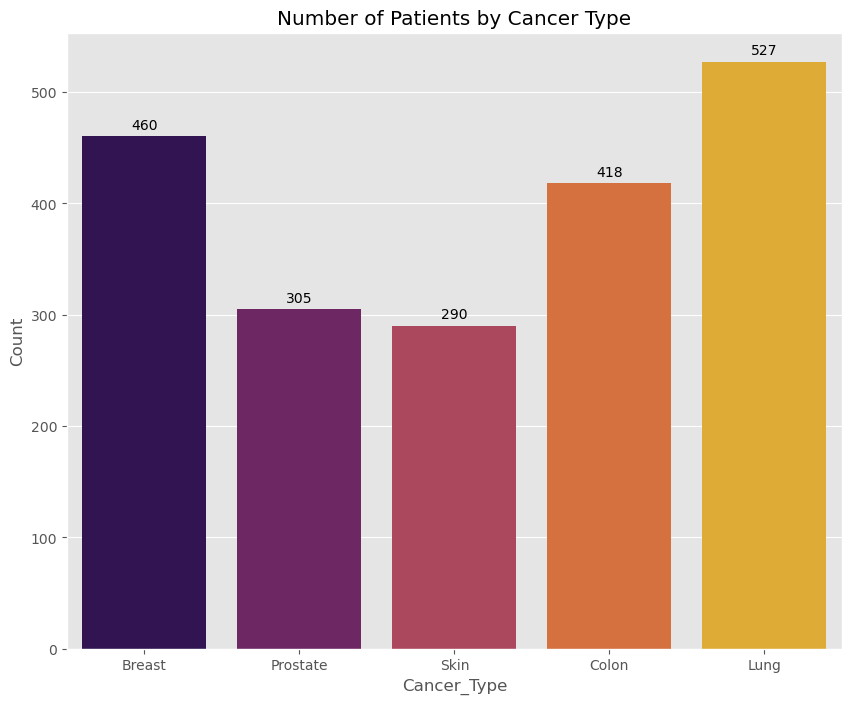

In [20]:
plt.figure(figsize=(10,8))
ax = sns.countplot(data=df, x='Cancer_Type', hue = 'Cancer_Type', palette = 'inferno' )
for container in ax.containers:
    ax.bar_label(container, padding = 3)
plt.title("Number of Patients by Cancer Type")
plt.ylabel("Count")
plt.show()

#### <i>&bull; Highest number of patients are diagnosed with Lung Cancer. 
#### <i>&bull; Breast cancer patients are second in line, followed by colon cancer.


<hr style="height:3px;border:none;background:linear-gradient(to right,#6c63ff,#00c9a7);">

## <i><b><center><u>Age Distribution of patients.

In [21]:
pd.crosstab(df['Age_Group'], df['Cancer_Type'])

Cancer_Type,Breast,Colon,Lung,Prostate,Skin
Age_Group,,,,,
Young (25-39),13,3,12,0,3
Middle-aged (40-59),161,162,188,30,107
Senior (60-74),240,214,292,144,153
Elderly (75+),46,39,35,131,27


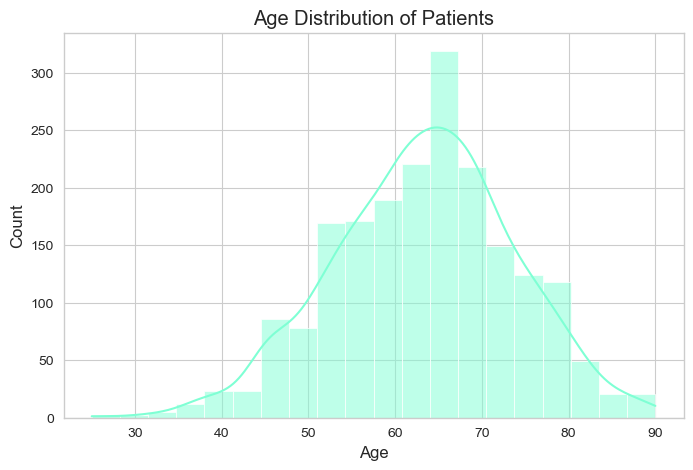

In [89]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=20, kde=True, color='aquamarine')
plt.title('Age Distribution of Patients')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

#### <i>&bull; Distribution is roughly symmetric.
#### <i>&bull; Cancer incidence is rare in younger individuals in this dataset.
#### <i>&bull; 60–74 is the most vulnerable age group, Cancer risk peaks in late adulthood. 

<hr style="height:3px;border:none;background:linear-gradient(to right,#6c63ff,#00c9a7);">

<div style="display:flex; align-items:center; gap:20px;">
    <img src="https://static.vecteezy.com/system/resources/thumbnails/075/703/440/small/silhouettes-of-people-exercising-in-various-poses-against-a-white-background-exercise-fitness-vector.jpg"
         width="210">
 <h1><u><I><center><b>     BMI Distribution of the patients.</center></h2> 
        <div style="display:flex; align-items:center; gap:20px;">
</div>

In [23]:
df[['Obesity', 'Physical_Activity_Level']].corr()

,Obesity,Physical_Activity_Level
Obesity,1.000000,0.016568
Physical_Activity_Level,0.016568,1.000000


In [24]:
df[['BMI', 'Obesity']].corr()

,BMI,Obesity
BMI,1.000000,0.005941
Obesity,0.005941,1.000000


In [25]:
df.groupby('Cancer_Type')[['Obesity', 'Physical_Activity_Level', 'BMI']].mean()

,Obesity,Physical_Activity_Level,BMI
Cancer_Type,,,
Breast,8.267391,5.180435,26.017609
Colon,5.160287,5.066986,26.177990
Lung,5.299810,4.956357,26.183871
Prostate,5.383607,4.236066,26.376721
Skin,5.310345,5.075862,26.249655


#### <i>&bull;  Breast cancer patients have the highest average obesity score, while colon cancer patients have the lowest. The other cancer types fall in between.
#### <i>&bull;  Prostate cancer patients have notably lower physical activity levels than the rest, while breast cancer patients are more active on average.


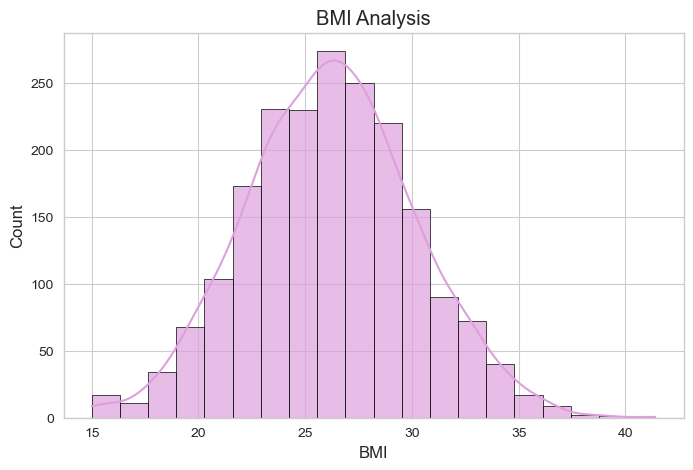

In [88]:
plt.figure(figsize=(8,5))

sns.histplot(df['BMI'], bins=20, kde=True, color='plum', edgecolor ='black', alpha=0.7)
plt.title('BMI Analysis')
plt.show()

#### <i>&bull; BMI differences are relatively small across cancer types (all around 26, which is slightly overweight).
#### <i>&bull; Very few underweight patients.

<hr style="height:3px;border:none;background:linear-gradient(to right,#6c63ff,#00c9a7);">

<div style="display:flex; align-items:center; gap:20px;">
    <img src="https://t4.ftcdn.net/jpg/03/09/95/43/360_F_309954327_N0Yb0xA9cIMezU1qkWNdSbuc1WfXfbUs.jpg"
         width="210">
    <h1><u><I><center><b>The Smoking Score Distribution.</center></h2>
</div>

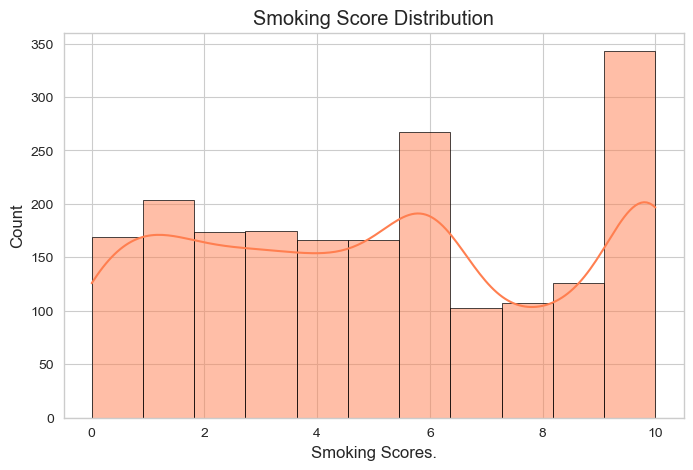

In [87]:
plt.figure(figsize=(8,5))
sns.histplot(df['Smoking'], bins=11, kde=True, color='coral', edgecolor ='black', alpha=0.5)
plt.title('Smoking Score Distribution')
plt.xlabel('Smoking Scores.')
plt.show()

#### <i>&bull; The dataset captures both non-smokers and heavy smokers well.
#### <i>&bull; Middle range is moderately populated. Most patients are heavy smokers (score 9–10).
#### <i>&bull; Non-smokers or light smokers are less frequent.

In [29]:
df.groupby('Cancer_Type')['Smoking'].mean().sort_values(ascending = False)

Cancer_Type
Lung        8.848197
Colon       3.971292
Prostate    3.849180
Breast      3.756522
Skin        3.755172
Name: Smoking, dtype: float64

#### <i>&bull; <font color = 'red'>Lung cancer has highest average smoking score, shows how criticaal and dangerous smoking can be.

<hr style="height:3px;border:none;background:linear-gradient(to right,#6c63ff,#00c9a7);">

 <i><b><center><u><font color = 'purple'>
<div style="display:flex; align-items:center; gap:20px;">
    <img src="https://thumbs.dreamstime.com/b/lung-cancer-21958114.jpg"
         width="210">
    <h1><u><I><center><b>Smoking Score & Lung Cancer Overall Risk Score.</center></h2>
</div>

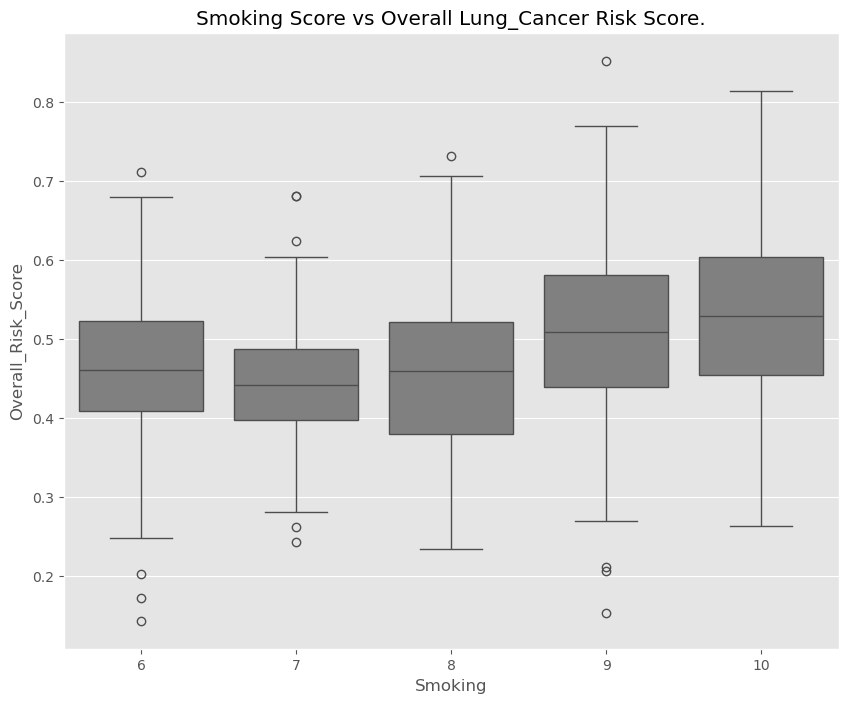

In [30]:
Lung_Cancer = df[df['Cancer_Type'] == 'Lung']

plt.figure(figsize=(10,8))
sns.boxplot(data=Lung_Cancer, x='Smoking', y='Overall_Risk_Score', color = 'grey')
plt.title("Smoking Score vs Overall Lung_Cancer Risk Score.")
plt.show()

#### <i>&bull; Risk increases as smoking score increases. High smoking intensity → higher lung cancer risk probability.

#### <i> &bull; Patients with smoking scores above 8 show a noticeable increase in the overall lung cancer risk score. The median risk rises significantly at smoking levels 9 and 10, indicating that heavy smoking behavior is strongly associated with increased lung cancer risk within the dataset.

#### <i> &bull; <font center = 'red'>Although smoking is a major contributor to lung cancer risk, the presence of both low and high outliers indicates that other lifestyle and environmental variables in the dataset also influence the overall risk score.

#### <i> &bull; <font color = 'red'> Low-risk outliers may be due to: good physical activity, better diet, lower air pollution exposure, no genetic predisposition.
#### <i> &bull; <font color = 'red'> High-risk outliers may be due to: high pollution exposure, occupational hazards, family history and genetic factors.

<hr style="height:3px;border:none;background:linear-gradient(to right,#6c63ff,#00c9a7);">

<div style="display:flex; align-items:center; gap:20px;">
    <img src="https://cdn-icons-png.flaticon.com/256/7438/7438544.png"
         width="120">
    <div style="display:flex; align-items:center; gap:20px;">
    <h1><u><I><center><b>  Analysis by Alcohol Consumption Score</center></h2>
        </div>
</div>

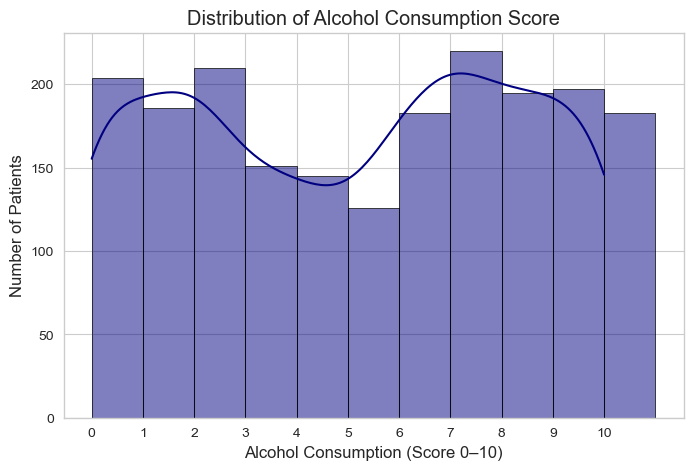

In [76]:
plt.figure(figsize=(8,5))

sns.histplot(df['Alcohol_Use'], bins=range(0, 12), kde=True, color = 'navy', edgecolor='black')

plt.title("Distribution of Alcohol Consumption Score")
plt.xlabel("Alcohol Consumption (Score 0–10)")
plt.ylabel("Number of Patients")

plt.xticks(range(0,11))
plt.show()

In [39]:
df.groupby('Cancer_Type')['Alcohol_Use'].mean().sort_values(ascending=False)

Cancer_Type
Lung        5.170778
Breast      5.132609
Prostate    5.042623
Skin        4.931034
Colon       4.822967
Name: Alcohol_Use, dtype: float64

#### <b><i>&bull; Alcohol consumption among patients is widely distributed across the full scale, suggesting no strong concentration of heavy or low drinkers in the dataset.

<hr style="height:3px;border:none;background:linear-gradient(to right,#6c63ff,#00c9a7);">

<div style="display:flex; align-items:center; gap:20px;">
    <img src="https://img.freepik.com/premium-vector/silhouette-old-people-with-older-children-pensioners-with-cane-their-son-daughter-stock-photo_213497-762.jpg"
         width="210">
    <h1><u><I><center><b>Analysis by Patient's Age & Gender.</center></h2>
</div>

In [19]:
df['Gender'].value_counts()

Gender
Female    1022
Male       978
Name: count, dtype: int64

#### <i><b> &bull; Female patients are slightly more in number.

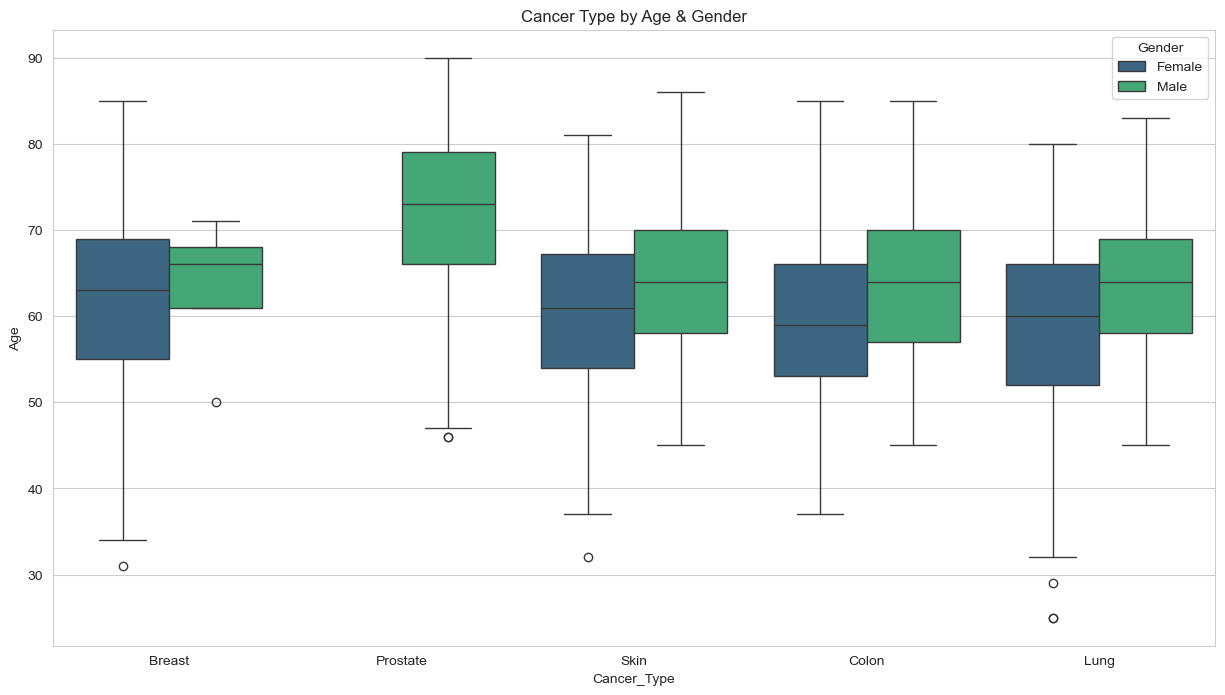

In [20]:
plt.figure(figsize=(15,8))
sns.set_style('whitegrid')
sns.boxplot(x='Cancer_Type', y='Age', hue='Gender', data=df, palette = 'viridis')
plt.title('Cancer Type by Age & Gender')
plt.show()

#### <i> &bull; Lung cancer cases are observed in both genders, with a slightly higher prevalence among male patients. 
#### <i> &bull; Majority of breast cancer cases are females, mostly in their 60s, with males showing slightly higher median age.
#### <i> &bull; Prostate cancer patients are the oldest group among all cancer types.
#### <i> &bull; Skin cancer affects both genders in similar age ranges, typically around late 50s.
#### <i> &bull; Colon cancer patients show moderate age distribution, with males slightly older.

<hr style="height:3px;border:none;background:linear-gradient(to right,#6c63ff,#00c9a7);">

In [21]:
df.groupby(['Cancer_Type', 'Gender'], observed = False).size().unstack()

Gender,Female,Male
Cancer_Type,,
Breast,455,5
Colon,197,221
Lung,238,289
Prostate,0,305
Skin,132,158


In [22]:
df.groupby(['Cancer_Type', 'Gender', 'Smoking'], observed = False).size().unstack()

Smoking             0   1   2   3   4   5   6   7   8   9    10
Cancer_Type Gender                                             
Breast      Female  55  62  55  53  52  50  67  17  14  14   16
            Male     0   1   0   1   0   2   1   0   0   0    0
Colon       Female  24  40  24  18  15  24  21   7   5  10    9
            Male    16  20  27  24  29  30  43   9   4  12    7
Lung        Female   0   0   0   0   0   0  46  29  36  29   98
            Male     0   0   0   0   0   0  18  23  28  38  182
Prostate    Female   0   0   0   0   0   0   0   0   0   0    0
            Male    39  44  27  43  37  31  34   9  12   9   20
Skin        Female  17  20  23  14  13  12  13   4   5   7    4
            Male    18  17  18  22  20  17  24   5   3   7    7

### <i><p> *The age distribution between male and female lung cancer patients appears similar, explains why the boxplot visualization shows comparable patterns for both groups.  Further analysis using smoking scores indicates that higher smoking levels are strongly associated with lung cancer cases in both genders, reinforcing smoking as a major risk factor in the dataset.

<hr style="height:3px;border:none;background:linear-gradient(to right,#6c63ff,#00c9a7);">

<div style="display:flex; align-items:center; gap:20px;">
    <img src="https://thumbs.dreamstime.com/b/healthy-unhealthy-food-human-heart-fresh-vegetables-one-side-junk-other-side-heart-concept-72925754.jpg"
        width="230">
 <h1><u><b><i>How Food Habits and Cancer Related??</h1></u></B></I></center>
<img src="https://st3.depositphotos.com/1529253/32557/v/450/depositphotos_325570854-stock-illustration-choice-between-healthy-and-unhealthy.jpg"
            width="200">
</div>

In [129]:
df.groupby('Cancer_Type')[['Diet_Red_Meat','Fruit_Veg_Intake','Calcium_Intake', 'Diet_Salted_Processed']].mean()

,Diet_Red_Meat,Fruit_Veg_Intake,Calcium_Intake,Diet_Salted_Processed
Cancer_Type,,,,
Breast,4.426087,5.060870,2.100000,4.265217
Colon,8.500000,3.622010,4.504785,5.909091
Lung,4.218216,5.609108,4.569260,4.286528
Prostate,4.465574,5.163934,4.383607,3.898361
Skin,4.155172,5.110345,4.437931,4.300000


#### <i> &bull;<font color = 'red'> Colon cancer shows elevated red meat and processed salt intake and very low intake of vegetable and fruits.
#### <i> &bull;<font color = 'red'> Breast cancer patients show a notably lower mean calcium intake score of around 2. 

<hr style="height:3px;border:none;background:linear-gradient(to right,#6c63ff,#00c9a7);">

<div style="display:flex; align-items:center; gap:20px;">
    <img src="https://i.etsystatic.com/19837560/r/il/ad3afb/3286439189/il_570xN.3286439189_gvwh.jpg"
        width ="250">
 <h1><u><b><i> The Correlation Matrix - Major Risk Factors by Life style.</h1></u></B></I></center>
</div>

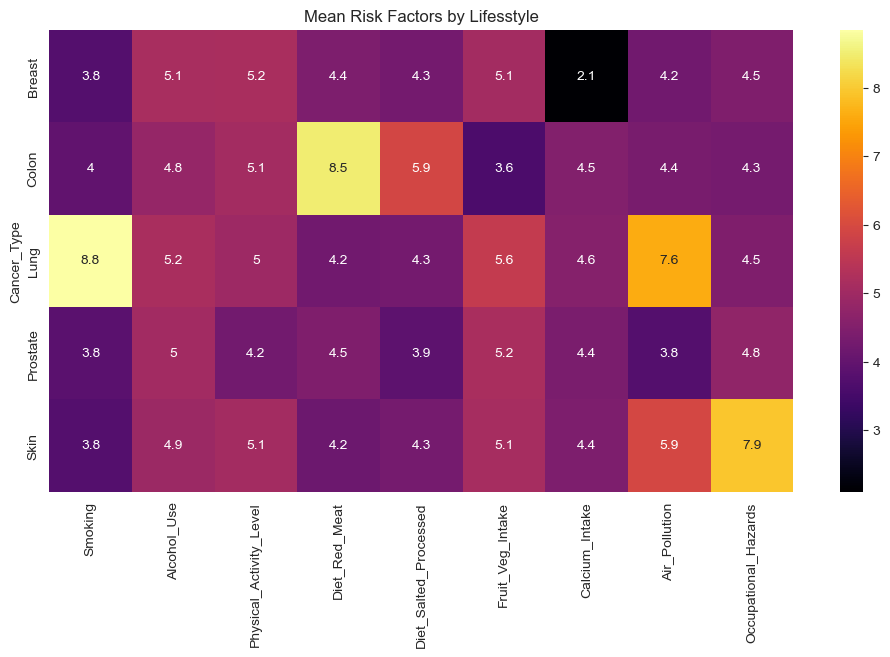

In [21]:
factors = ['Smoking','Alcohol_Use','Physical_Activity_Level',
           'Diet_Red_Meat','Diet_Salted_Processed','Fruit_Veg_Intake','Calcium_Intake','Air_Pollution', 'Occupational_Hazards']

mean_risk = df.groupby('Cancer_Type')[factors].mean()

plt.figure(figsize=(12,6))
sns.heatmap(mean_risk, annot=True, cmap='inferno')
plt.title("Mean Risk Factors by Lifesstyle")
plt.show()

#### <i> &bull;<font color = 'red'> Lung Cancer: Extremely high risk from Smoking and other notable risk is Air pollution.
#### <i> &bull;<font color = 'red'> Breast Cancer: Notably low intake of dietry calcium.
#### <i> &bull;<font color = 'red'> Colon Cancer: Very high risk from processed Red Meat, and another risk factor is the excessive use of processed salts. 
#### <i> &bull;<font color = 'red'> The fruits and vegetable intake is relatively low in Colon Cancer patients.
#### <i> &bull;<font color = 'red'> Skin Cancer: Highest risk factor is Occupational_Hazards; Air pollution also is identified as a major risk.
#### <i> &bull;<font color = 'red'> Physical activity levels are relatively similar across all patients, except for colon cancer patients.
#### <i> &bull;<font color = 'red'> Including processed salt in diet is not recommended.

<hr style="height:3px;border:none;background:linear-gradient(to right,#6c63ff,#00c9a7);">

<div style="width: 100%; display: table; margin: 0 auto;">
    <div style="display: flex; align-items: center; justify-content: center; gap: 30px; text-align: center;">
        <img src="https://cdn-icons-png.flaticon.com/512/2103/2103633.png" 
             style="width: 180px; min-width: 110px; height: auto;">
        <div style="flex-grow: 0;">
            <h1 style="margin: 0; text-decoration: underline; font-style: italic; white-space: nowrap;">
                <b>Genetic Risk Factors Analysis
            </h1>
        </div>
        <img src="https://cdn-icons-png.flaticon.com/512/2785/2785482.png" 
             style="width: 180px; min-width: 110px; height: auto;">     
    </div>
</div>

#### <i><b>  BRCA Mutation: BRCA genes are responsible for DNA repair. If mutated, Cells accumulate DNA damage and a higher cancer probability. BRCA mutation is strongly linked with Breast cancer, Ovarian cancer and sometimes prostate cancer. 

In [26]:
df.groupby(['Cancer_Type','BRCA_Mutation'], observed = False).size().unstack()

BRCA_Mutation,No,Yes
Cancer_Type,,
Breast,423,37
Colon,404,14
Lung,520,7
Prostate,301,4
Skin,287,3


<hr style="height:3px;border:none;background:linear-gradient(to right,#6c63ff,#00c9a7);">

#### <i><b>  H.pylori is a bacterium that infects the stomach. It is strongly associated with: Gastric cancer, Digestive inflammation and Ulcers.

In [29]:
pd.crosstab(df['Cancer_Type'], df['H_Pylori_Infection'])

H_Pylori_Infection,No,Yes
Cancer_Type,,
Breast,354,106
Colon,342,76
Lung,436,91
Prostate,251,54
Skin,224,66


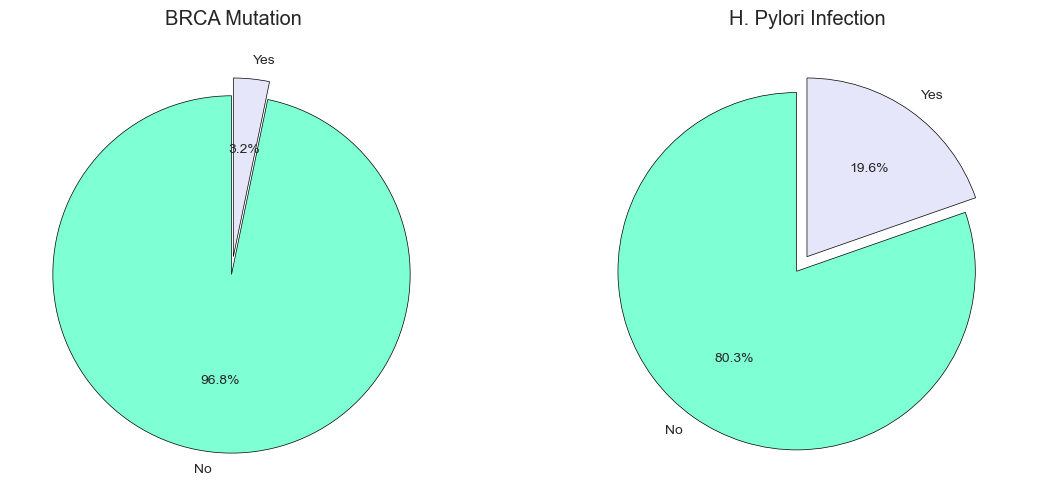

In [112]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
my_explode = [0.1, 0] 
df['BRCA_Mutation'].value_counts().plot.pie(
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor':'black'},
    colors=['aquamarine', 'lavender'],
    explode=my_explode)
plt.title('BRCA Mutation')
plt.ylabel('')

plt.subplot(1,2,2)
my_explode = [0.1, 0] 

df['H_Pylori_Infection'].value_counts().plot.pie(
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor':'black'},
    colors=['aquamarine', 'lavender'],
    explode=my_explode)
plt.title('H. Pylori Infection')
plt.ylabel('')

plt.tight_layout()
plt.show()

#### <i>&bull; From the pie charts, it is evident that BRCA mutation and H. Pylori infection are relatively rare among the patients. 
#### <i>&bull; Breast cancer has the highest proportion among these cancers, but still relatively small compared to non-mutated cases.
#### <i>&bull; Overall, H. Pylori infection is more common than BRCA mutation but still not dominant. Around 20–25% of patients are infected.
#### <i>&bull; Colon cancer has the highest absolute count of infected patients, aligning with H. Pylori’s known association with gastrointestinal issues.

<hr style="height:3px;border:none;background:linear-gradient(to right,#6c63ff,#00c9a7);">

In [23]:
pd.pivot_table(
    df,
    values=['Family_History', 'Overall_Risk_Score' ],
    index='Cancer_Type',
    aggfunc='mean'
)

,Family_History,Overall_Risk_Score
Cancer_Type,,
Breast,0.210870,0.434099
Colon,0.198565,0.466093
Lung,0.185958,0.499914
Prostate,0.203279,0.388936
Skin,0.168966,0.456224


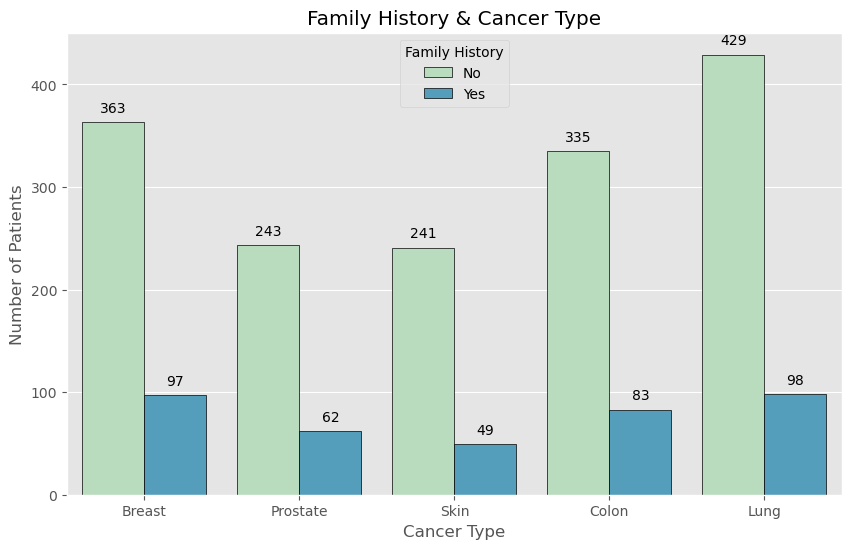

In [24]:
plt.figure(figsize=(10,6))

ax = sns.countplot(
    data=df,
    x='Cancer_Type',
    hue=df['Family_History'].map({0:'No', 1:'Yes'}),
    palette='GnBu', edgecolor ='black')

for containers in ax.containers:
    ax.bar_label(containers, padding = 5)
    
plt.title('Family History & Cancer Type')
plt.xlabel('Cancer Type')
plt.ylabel('Number of Patients')
plt.legend(title='Family History')
plt.show()

#### <i>&bull; The vast majority of patients do not have a family history of the disease.
#### <i>&bull; Lung Cancer represents the highest total number of patients in the dataset, also has the highest number of patients who report no family history.
#### <i>&bull; Breast Cancer has the second-highest total patient count. Notably, it has nearly the same number of "Yes" cases (97) as Lung Cancer (98), despite having fewer total patients.

<hr style="height:3px;border:none;background:linear-gradient(to right,#6c63ff,#00c9a7);">

<div style="width: 100%; display: table; margin: 0 auto;">
    <div style="display: flex; align-items: center; justify-content: center; gap: 30px; text-align: center;">
        <img src="https://media.istockphoto.com/id/1177203762/vector/obesity-people-wearing-sports-uniform-doing-fitness-exercises-set-fat-men-and-women-doing.jpg?s=612x612&w=0&k=20&c=x9Qi9e-M0Cu6lnJ4ikb4H9HKGai11Ob-u0-7XSQ4r64=" 
             style="width: 270px; min-width: 110px; height: auto;">
<div style="flex-grow: 0;">
            <h1 style="margin: 0; text-decoration: underline; font-style: italic; white-space: nowrap;">
                <b>Obesity & Physical Activity
            </h1>
        </div>
        <img src="https://static.vecteezy.com/system/resources/thumbnails/073/520/378/small/black-stick-figure-icons-of-exercise-and-sports-on-a-white-background-vector.jpg" 
             style="width: 270px; min-width: 110px; height: auto;">     
    </div>
</div>

In [38]:
df.groupby('Cancer_Type')[
    ['Obesity','Physical_Activity_Level']
].mean()

,Obesity,Physical_Activity_Level
Cancer_Type,,
Breast,8.267391,5.180435
Colon,5.160287,5.066986
Lung,5.299810,4.956357
Prostate,5.383607,4.236066
Skin,5.310345,5.075862


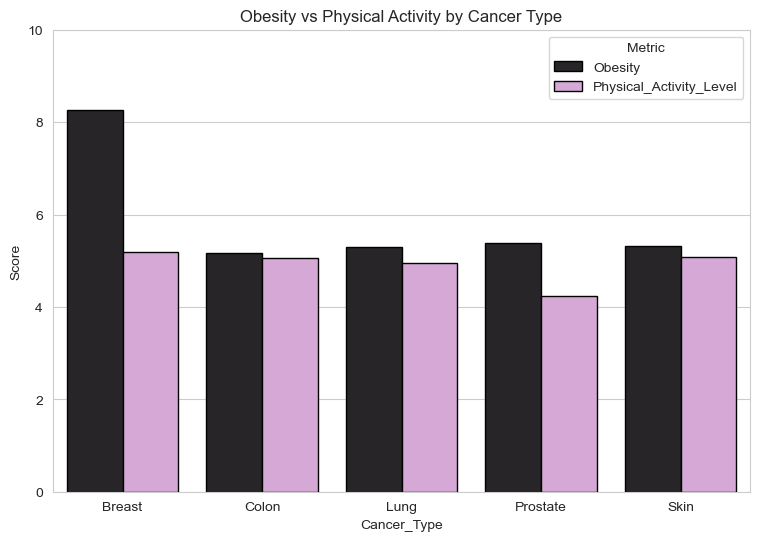

In [16]:
data = {
    'Cancer_Type': ['Breast', 'Colon', 'Lung', 'Prostate', 'Skin'],
    'Obesity': [8.267391, 5.160287, 5.299810, 5.383607, 5.310345],
    'Physical_Activity_Level': [5.180435, 5.066986, 4.956357, 4.236066, 5.075862]
}

df1 = pd.DataFrame(data)
df_plot = df1.set_index('Cancer_Type').stack().reset_index()
df_plot.columns = ['Cancer_Type', 'Metric', 'Score']
sns.set_style('whitegrid')
plt.figure(figsize=(9,6))
sns.barplot(data=df_plot, x='Cancer_Type', y='Score', hue='Metric', palette='dark:plum', edgecolor ='black')

plt.ylim(0,10)
plt.title("Obesity vs Physical Activity by Cancer Type")
plt.show()

#### <i>&bull; Breast cancer patients show significantly higher obesity levels than other cancer types.
#### <i>&bull; Prostate cancer patients have the lowest physical activity level.
#### <i>&bull; Colon, lung, and skin cancers show similar lifestyle patterns.
#### <i>&bull;<font color= 'red'> * Lifestyle factors like obesity and activity could influence cancer risk differently across cancer types.

<hr style="height:3px;border:none;background:linear-gradient(to right,#6c63ff,#00c9a7);">

<div style="display:flex; align-items:center; gap:20px;">
    <img src="https://www.shutterstock.com/image-vector/pollution-set-icon-environmental-damage-260nw-2489263803.jpg"
        width ="320">
 <h1><u><b><i><center> Environmental Factors & Cancer Risks.</h1></u></B></I></center>
</div>

In [49]:
df.groupby('Cancer_Type')[['Air_Pollution','Occupational_Hazards']].mean()

,Air_Pollution,Occupational_Hazards
Cancer_Type,,
Breast,4.234783,4.460870
Colon,4.366029,4.313397
Lung,7.607211,4.459203
Prostate,3.757377,4.760656
Skin,5.924138,7.934483


<hr style="height:3px;border:none;background:linear-gradient(to right,#6c63ff,#00c9a7);">

In [152]:
df[['Air_Pollution','Occupational_Hazards','Overall_Risk_Score']].corr()

,Air_Pollution,Occupational_Hazards,Overall_Risk_Score
Air_Pollution,1.000000,0.087211,0.501379
Occupational_Hazards,0.087211,1.000000,0.359445
Overall_Risk_Score,0.501379,0.359445,1.000000


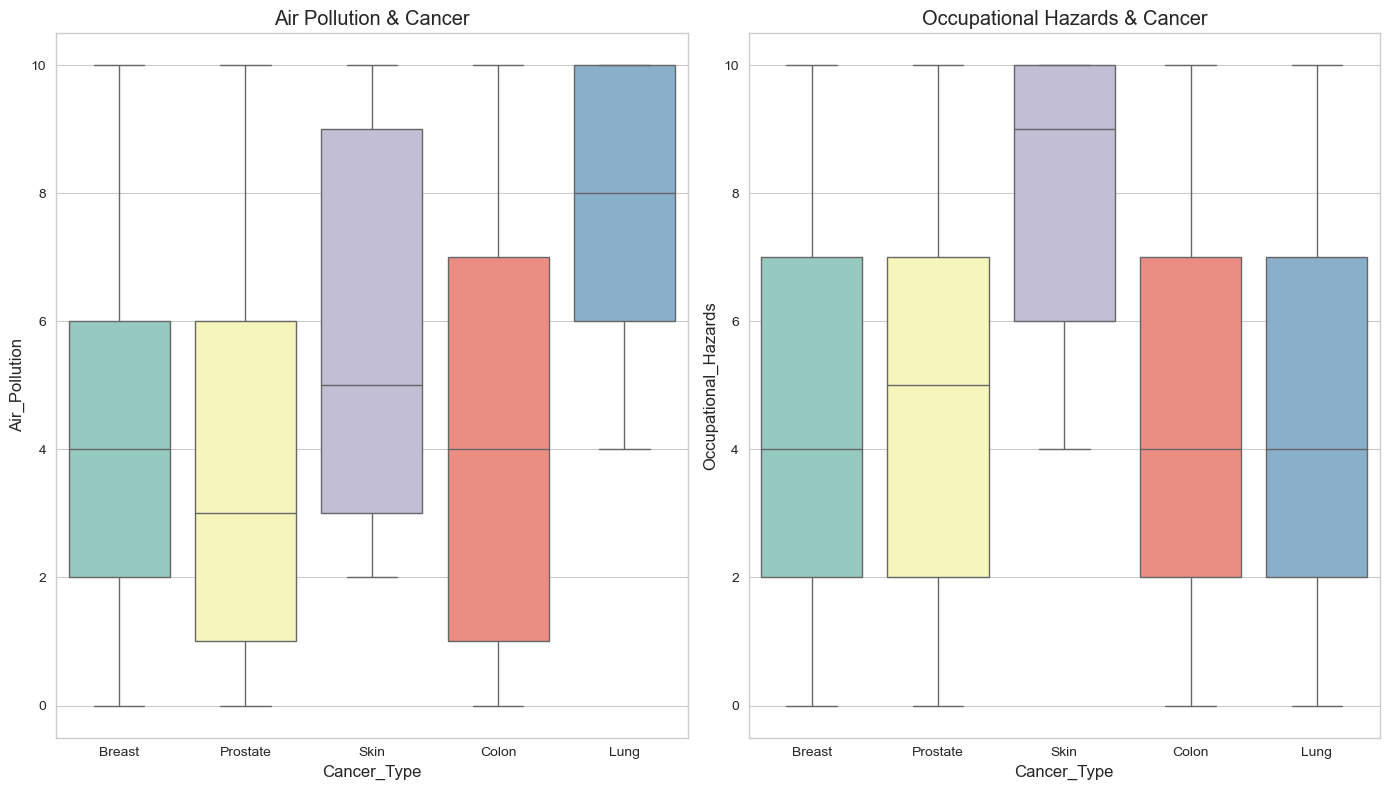

In [140]:
factors = ['Air_Pollution', 'Occupational_Hazards']

fig, axes = plt.subplots(1, 2, figsize=(14, 8))

sns.boxplot(data=df, x='Cancer_Type', y='Air_Pollution', ax=axes[0], hue = 'Cancer_Type', palette='Set3')
axes[0].set_title('Air Pollution & Cancer')

sns.boxplot(data=df, x='Cancer_Type', y='Occupational_Hazards', ax=axes[1],hue = 'Cancer_Type',  palette='Set3')
axes[1].set_title('Occupational Hazards & Cancer')

plt.tight_layout()
plt.show()

#### <i><b><font color = 'red'> &bull; * Frequent exposure to Air Pollution causes Lung Cancer and, Occupational Hazards can cause Skin Cancer.
#### <i><b> &bull; Air_Pollution & Smoking contributes to a high risk score.
#### <i><b> &bull; Occupational_Hazards has a moderate positive environmental contribution.

<hr style="height:3px;border:none;background:linear-gradient(to right,#6c63ff,#00c9a7);">

# <i><b><center><u> INSIGHTS AND FINDINGS

#### <i>This report is solely based on the findings from the dataset take from the website: https://www.kaggle.com/datasets/tarekmasryo/cancer-risk-factors-dataset 
#### <i> &bull; Lifestyle habits increase overall cancer risk. Cancer cases increase sharply after 40 and number pf females patients are slightly larger. Lung cancer dominates across most age groups. Prostate cancer increases significantly in older ages. Excessive consumption of red meat may result in Colon cancer.
#### <i> &bull; BRCA mutation is a relatively minor risk factor in this dataset, primarily concentrated in breast cancer patients. Most patients across all cancer types do not have this mutation. H. Pylori infection is more common in colon cancer but affects only about a quarter of patients. 

#### <i> &bull; Family history does not appear to be the primary driver or a major factor for the majority of cancer cases.

#### <i> &bull; Higher the smoking intensity, higher the lung cancer risk probability. The alcohol consumption score is relatively evenly distributed across the dataset, suggests that alcohol consumption varies moderately among patients and may act as a contributing factor rather than a dominant risk indicator.
#### <i> &bull; Transitioning to a balanced diet rich in fruits, vegetables, and whole grains while limiting red and processed meats can significantly reduce risk.

#### <i> &bull; The comparison of obesity and physical activity levels across cancer types reveals noticeable lifestyle differences among patients. 
#### <i> &bull; When analyzing air pollution and occupational hazards, patterns suggested that environmental exposure is associated with cancer risk levels.

#### <i> &bull; In short, while some factors like age and genetics are beyond our control, a significant portion of cancer risk is manageable through conscious daily choices. Up to 50% of cancer deaths are linked to preventable risk factors that we can modify. Ultimately, while there is no way to guarantee a cancer-free life, adopting these evidence-based lifestyle changes and staying current with regular screenings empowers you to take charge of your health and foster a healthier future.


<hr style="height:3px;border:none;background:linear-gradient(to right,#6c63ff,#00c9a7);">